# Satellite 3F — Comparación limpia de transformaciones previas + QNN 1q + NQK 1-to-n

Este notebook compara cuatro transformaciones previas hacia **3 features**:

1. PCA
2. ICA
3. AE-lineal
4. AE-no-lineal

La comparación se hace con **5 folds estratificados**. En cada fold, todo lo que aprende de los datos se ajusta **solo con el train del fold**: `StandardScaler`, transformación previa, `MinMaxScaler`, autoencoders, QNN y SVM. El test fold queda completamente fuera hasta evaluación.

Flujo por fold:

`z64 → transformación 3F sin leakage → QNN 1q → NQK 1-to-n vectorizado por estados → SVM precomputed → métricas`

Las salidas se guardan en carpetas separadas para no mezclar resultados.

In [1]:
# ============================================================
# Celda 0 — Imports, configuración global y carga del dataset
# ============================================================
import os, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pennylane as qml
from tqdm.auto import tqdm

from sklearn import svm
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, roc_auc_score
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# -----------------------------
# Configuración principal
# -----------------------------
SEED = 99
N_SPLITS = 5
NUM_FEATURES = 3

# QNN 1 qubit
LAYERS = 6
EPOCHS_QNN = 60
BATCH_SIZE_QNN = 32
LEARNING_RATE_QNN = 0.006
WEIGHT_DECAY_QNN = 1e-5
SCALE = np.pi / 2

# Autoencoders
AE_EPOCHS = 120
AE_BATCH_SIZE = 128
AE_LR = 1e-3
AE_WEIGHT_DECAY = 1e-5
AE_HIDDEN = 32

# NQK 1-to-n
NQK_QUBITS_LIST = [1, 2, 3]
CHUNK_PATCHES = 1048576

# None = usa todo el conjunto disponible.
# Para prueba rápida, usa por ejemplo 2000.
SAMPLE_SIZE = None

DATA_PATH = r"C:\Users\lapic\datasets\z64_dimensionality_reduction_5fold\distr_sol_pv_segm_embeddings_v2"
PROJECT_DIR = "Satellite_3F_TransformComparison_5fold_GPU_vectorized"
TABLES_DIR = os.path.join(PROJECT_DIR, "tables")
FIGURES_DIR = os.path.join(PROJECT_DIR, "figures")
PARAMS_DIR = os.path.join(PROJECT_DIR, "parameters")
MATRICES_DIR = os.path.join(PROJECT_DIR, "kernel_matrices")
ROC_DIR = os.path.join(PROJECT_DIR, "roc")
TRANSFORM_DIR = os.path.join(PROJECT_DIR, "transformed_features")

for folder in [PROJECT_DIR, TABLES_DIR, FIGURES_DIR, PARAMS_DIR, MATRICES_DIR, ROC_DIR, TRANSFORM_DIR]:
    os.makedirs(folder, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.set_float32_matmul_precision("high")
print("DEVICE:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


def resolve_npz_path(path):
    if os.path.exists(path):
        return path
    if not path.lower().endswith(".npz") and os.path.exists(path + ".npz"):
        return path + ".npz"
    raise FileNotFoundError(f"No se encontró DATA_PATH: {path}")


def load_full_dataset(path=DATA_PATH, sample_size=SAMPLE_SIZE, seed=SEED):
    path = resolve_npz_path(path)
    data = np.load(path, allow_pickle=True)
    X = data["features"].astype(np.float32)
    y = data["label"].astype(np.int64)
    print("Dataset original:", X.shape, y.shape)
    print("Clases originales:", dict(zip(*np.unique(y, return_counts=True))))

    if sample_size is not None and sample_size < len(X):
        from sklearn.model_selection import train_test_split
        X, _, y, _ = train_test_split(
            X, y, train_size=sample_size, random_state=seed, stratify=y
        )
        print("Dataset muestreado:", X.shape, y.shape)
    else:
        print("SAMPLE_SIZE=None: usando todo el conjunto disponible.")
    print("Clases usadas:", dict(zip(*np.unique(y, return_counts=True))))
    return X, y

X_all, y_all = load_full_dataset()

config = {
    "seed": SEED,
    "n_splits": N_SPLITS,
    "num_features": NUM_FEATURES,
    "layers": LAYERS,
    "epochs_qnn": EPOCHS_QNN,
    "batch_size_qnn": BATCH_SIZE_QNN,
    "learning_rate_qnn": LEARNING_RATE_QNN,
    "weight_decay_qnn": WEIGHT_DECAY_QNN,
    "ae_epochs": AE_EPOCHS,
    "ae_batch_size": AE_BATCH_SIZE,
    "ae_lr": AE_LR,
    "ae_weight_decay": AE_WEIGHT_DECAY,
    "ae_hidden": AE_HIDDEN,
    "nqk_qubits_list": NQK_QUBITS_LIST,
    "chunk_patches": CHUNK_PATCHES,
    "sample_size": SAMPLE_SIZE,
    "data_path": DATA_PATH,
    "project_dir": PROJECT_DIR,
    "device": str(DEVICE),
}
with open(os.path.join(PROJECT_DIR, "config.json"), "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

C:\Users\lapic\QML2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE: cuda
GPU: NVIDIA GeForce RTX 3090
Dataset original: (20976, 64) (20976,)
Clases originales: {0: 10293, 1: 10683}
SAMPLE_SIZE=None: usando todo el conjunto disponible.
Clases usadas: {0: 10293, 1: 10683}


In [2]:
# ============================================================
# Celda 1 — Transformaciones previas 3F sin leakage
# ============================================================
# Importante: cada transformación se ajusta SOLO con X_train del fold.
# Después se transforma X_test del fold. Así no hay aprendizaje compartido.

class LinearAE(nn.Module):
    def __init__(self, input_dim, latent_dim=3):
        super().__init__()
        self.encoder = nn.Linear(input_dim, latent_dim)
        self.decoder = nn.Linear(latent_dim, input_dim)
    def forward(self, x):
        z = self.encoder(x)
        xhat = self.decoder(z)
        return xhat
    def encode(self, x):
        return self.encoder(x)

class NonLinearAE(nn.Module):
    def __init__(self, input_dim, latent_dim=3, hidden=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, input_dim),
        )
    def forward(self, x):
        z = self.encoder(x)
        xhat = self.decoder(z)
        return xhat
    def encode(self, x):
        return self.encoder(x)


def train_autoencoder(X_train_std, ae_type, fold, transform_name):
    input_dim = X_train_std.shape[1]
    if ae_type == "linear":
        model = LinearAE(input_dim=input_dim, latent_dim=NUM_FEATURES).to(DEVICE)
    elif ae_type == "nonlinear":
        model = NonLinearAE(input_dim=input_dim, latent_dim=NUM_FEATURES, hidden=AE_HIDDEN).to(DEVICE)
    else:
        raise ValueError(ae_type)

    X_t = torch.tensor(X_train_std, dtype=torch.float32, device=DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=AE_LR, weight_decay=AE_WEIGHT_DECAY)
    loss_fn = nn.MSELoss()
    history = []

    gen = torch.Generator(device=DEVICE)
    gen.manual_seed(SEED + fold)

    for epoch in range(1, AE_EPOCHS + 1):
        idx = torch.randperm(X_t.shape[0], device=DEVICE, generator=gen)
        losses = []
        model.train()
        for i in range(0, X_t.shape[0], AE_BATCH_SIZE):
            xb = X_t[idx[i:i+AE_BATCH_SIZE]]
            opt.zero_grad(set_to_none=True)
            xhat = model(xb)
            loss = loss_fn(xhat, xb)
            loss.backward()
            opt.step()
            losses.append(float(loss.detach().cpu()))
        history.append({"epoch": epoch, "loss": float(np.mean(losses))})

    hist_df = pd.DataFrame(history)
    hist_path = os.path.join(TABLES_DIR, f"ae_history_{transform_name}_fold{fold}.csv")
    hist_df.to_csv(hist_path, index=False)

    model_path = os.path.join(PARAMS_DIR, f"ae_{transform_name}_fold{fold}.pt")
    torch.save(model.state_dict(), model_path)
    return model, hist_df, model_path


def encode_autoencoder(model, X_std, chunk_size=CHUNK_PATCHES):
    model.eval()
    X_t = torch.tensor(X_std, dtype=torch.float32, device=DEVICE)
    zs = []
    with torch.no_grad():
        for i in range(0, X_t.shape[0], chunk_size):
            z = model.encode(X_t[i:i+chunk_size])
            zs.append(z.detach().cpu().numpy())
    return np.concatenate(zs, axis=0).astype(np.float32)


def fit_transform_3f_no_leakage(X_train_raw, X_test_raw, y_train, fold, transform_name):
    # 1) StandardScaler solo con train
    scaler = StandardScaler()
    X_train_std = scaler.fit_transform(X_train_raw).astype(np.float32)
    X_test_std = scaler.transform(X_test_raw).astype(np.float32)

    extra_info = {}

    # 2) Reducción a 3 features solo con train
    if transform_name == "PCA":
        reducer = PCA(n_components=NUM_FEATURES, random_state=SEED + fold)
        Z_train = reducer.fit_transform(X_train_std).astype(np.float32)
        Z_test = reducer.transform(X_test_std).astype(np.float32)
        extra_info["explained_variance_ratio_sum"] = float(reducer.explained_variance_ratio_.sum())
        extra_info["reducer"] = "PCA"

    elif transform_name == "ICA":
        reducer = FastICA(
            n_components=NUM_FEATURES,
            random_state=SEED + fold,
            max_iter=2000,
            tol=1e-4,
            whiten="unit-variance",
        )
        Z_train = reducer.fit_transform(X_train_std).astype(np.float32)
        Z_test = reducer.transform(X_test_std).astype(np.float32)
        extra_info["reducer"] = "FastICA"

    elif transform_name == "AE_linear":
        model, hist_df, model_path = train_autoencoder(X_train_std, "linear", fold, transform_name)
        Z_train = encode_autoencoder(model, X_train_std)
        Z_test = encode_autoencoder(model, X_test_std)
        extra_info["ae_model_path"] = model_path
        extra_info["ae_final_loss"] = float(hist_df["loss"].iloc[-1])

    elif transform_name == "AE_nonlinear":
        model, hist_df, model_path = train_autoencoder(X_train_std, "nonlinear", fold, transform_name)
        Z_train = encode_autoencoder(model, X_train_std)
        Z_test = encode_autoencoder(model, X_test_std)
        extra_info["ae_model_path"] = model_path
        extra_info["ae_final_loss"] = float(hist_df["loss"].iloc[-1])

    else:
        raise ValueError(f"Transformación no reconocida: {transform_name}")

    # 3) Escalado angular fit SOLO en Z_train
    angle_scaler = MinMaxScaler(feature_range=(-np.pi/2, np.pi/2))
    Z_train_ang = angle_scaler.fit_transform(Z_train).astype(np.float32)
    Z_test_ang = angle_scaler.transform(Z_test).astype(np.float32)
    Z_train_ang = np.clip(Z_train_ang, -np.pi/2, np.pi/2).astype(np.float32)
    Z_test_ang = np.clip(Z_test_ang, -np.pi/2, np.pi/2).astype(np.float32)

    # Guardar features transformados por fold para reproducibilidad
    np.savez(
        os.path.join(TRANSFORM_DIR, f"features_{transform_name}_fold{fold}.npz"),
        X_train_3f=Z_train_ang,
        X_test_3f=Z_test_ang,
        y_train=y_train,
    )

    return Z_train_ang, Z_test_ang, extra_info

TRANSFORMS = ["PCA", "ICA", "AE_linear", "AE_nonlinear"]
print("Transformaciones a comparar:", TRANSFORMS)

Transformaciones a comparar: ['PCA', 'ICA', 'AE_linear', 'AE_nonlinear']


In [3]:
# ============================================================
# Celda 2 — QNN 1 qubit vectorizada y entrenamiento por fold
# ============================================================
dev_1q = qml.device("default.qubit", wires=1)

@qml.qnode(dev_1q, interface="torch", diff_method="backprop")
def QNN1_batch(params, X):
    # X: (B, 3)
    for l in range(params.shape[0]):
        qml.Rot(X[:, 0], X[:, 1], X[:, 2], wires=0)
        qml.Rot(params[l, 0], params[l, 1], params[l, 2], wires=0)
    return qml.expval(qml.PauliZ(wires=0))


def v_QNN1(params, X, chunk_size=CHUNK_PATCHES):
    outs = []
    for i in range(0, X.shape[0], chunk_size):
        outs.append(QNN1_batch(params, X[i:i+chunk_size]))
    return torch.cat([o.reshape(-1) for o in outs], dim=0)


def qnn_loss(params, X, y):
    y_mapped = torch.where(y == 0, -1.0, 1.0).float()
    z = v_QNN1(params, X, chunk_size=CHUNK_PATCHES)
    return torch.mean((z - y_mapped) ** 2)

@torch.no_grad()
def qnn_scores(params, X):
    return v_QNN1(params, X, chunk_size=CHUNK_PATCHES).detach().cpu().numpy()

@torch.no_grad()
def qnn_predict(params, X, threshold=0.0):
    z = v_QNN1(params, X, chunk_size=CHUNK_PATCHES)
    return torch.where(z < threshold, 0, 1).long().detach().cpu().numpy()


def iterate_minibatches(X, y, batch_size, shuffle=True, seed=SEED):
    n = X.shape[0]
    if shuffle:
        idx = torch.randperm(n, device=X.device)
        X, y = X[idx], y[idx]
    for i in range(0, n, batch_size):
        yield X[i:i+batch_size], y[i:i+batch_size]


def make_init_params(seed, layers=LAYERS):
    gen = torch.Generator(device=DEVICE)
    gen.manual_seed(seed)
    params = torch.empty(layers, 3, dtype=torch.float32, device=DEVICE).uniform_(-SCALE, SCALE, generator=gen)
    return torch.nn.Parameter(params)


def compute_metrics(y_true, y_pred, y_score=None):
    acc = accuracy_score(y_true, y_pred) * 100
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0) * 100
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0) * 100
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0) * 100
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    auc = np.nan
    if y_score is not None and len(np.unique(y_true)) == 2:
        auc = roc_auc_score(y_true, y_score)
    return {
        "acc": acc, "f1": f1, "precision": prec, "recall": rec, "auc": auc,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


def train_qnn_1q_fold(X_train_np, y_train_np, X_test_np, y_test_np, fold, transform_name):
    X_train = torch.tensor(X_train_np, dtype=torch.float32, device=DEVICE)
    y_train = torch.tensor(y_train_np, dtype=torch.long, device=DEVICE)
    X_test = torch.tensor(X_test_np, dtype=torch.float32, device=DEVICE)

    params = make_init_params(SEED + 1000 * fold + 17, LAYERS)
    optimizer = torch.optim.Adam([params], lr=LEARNING_RATE_QNN, weight_decay=WEIGHT_DECAY_QNN)
    history = []
    best_train_loss = np.inf
    best_params_np = None
    t0_all = time.time()

    for epoch in range(1, EPOCHS_QNN + 1):
        t0 = time.time()
        losses = []
        for Xb, yb in iterate_minibatches(X_train, y_train, BATCH_SIZE_QNN, shuffle=True):
            optimizer.zero_grad(set_to_none=True)
            loss = qnn_loss(params, Xb, yb)
            loss.backward()
            optimizer.step()
            losses.append(float(loss.detach().cpu()))
        mean_loss = float(np.mean(losses))
        if mean_loss < best_train_loss:
            best_train_loss = mean_loss
            best_params_np = params.detach().cpu().numpy().copy()

        # Métricas ligeras por época. Si tarda demasiado, puedes comentar estas 4 líneas.
        y_train_pred = qnn_predict(params, X_train)
        y_test_pred = qnn_predict(params, X_test)
        train_acc = accuracy_score(y_train_np, y_train_pred) * 100
        test_acc = accuracy_score(y_test_np, y_test_pred) * 100
        history.append({"epoch": epoch, "loss": mean_loss, "train_acc": train_acc, "test_acc": test_acc, "seconds": time.time() - t0})
        print(f"[{transform_name} | fold {fold}] Epoch {epoch:03d}/{EPOCHS_QNN} | loss={mean_loss:.6f} | train_acc={train_acc:.2f}% | test_acc={test_acc:.2f}% | dt={history[-1]['seconds']:.1f}s")

    params_1q = best_params_np.astype(np.float32)
    params_path = os.path.join(PARAMS_DIR, f"qnn_1q_params_{transform_name}_fold{fold}.npy")
    np.save(params_path, params_1q)

    hist_df = pd.DataFrame(history)
    hist_path = os.path.join(TABLES_DIR, f"qnn_history_{transform_name}_fold{fold}.csv")
    hist_df.to_csv(hist_path, index=False)

    params_t = torch.tensor(params_1q, dtype=torch.float32, device=DEVICE)
    y_train_score = qnn_scores(params_t, X_train)
    y_test_score = qnn_scores(params_t, X_test)
    y_train_pred = np.where(y_train_score < 0.0, 0, 1).astype(np.int64)
    y_test_pred = np.where(y_test_score < 0.0, 0, 1).astype(np.int64)

    train_m = compute_metrics(y_train_np, y_train_pred, y_train_score)
    test_m = compute_metrics(y_test_np, y_test_pred, y_test_score)

    pred_path = os.path.join(TABLES_DIR, f"qnn_predictions_{transform_name}_fold{fold}.csv")
    pd.DataFrame({"y_true": y_test_np, "y_pred": y_test_pred, "score": y_test_score}).to_csv(pred_path, index=False)

    fpr_train, tpr_train, thr_train = roc_curve(y_train_np, y_train_score)
    fpr_test, tpr_test, thr_test = roc_curve(y_test_np, y_test_score)
    roc_path = os.path.join(ROC_DIR, f"qnn_roc_{transform_name}_fold{fold}.npz")
    np.savez(roc_path, fpr_train=fpr_train, tpr_train=tpr_train, thr_train=thr_train,
             fpr_test=fpr_test, tpr_test=tpr_test, thr_test=thr_test,
             auc_train=train_m["auc"], auc_test=test_m["auc"])

    row = {
        "transform": transform_name,
        "fold": fold,
        "model": "QNN_1q_direct",
        "qubits": 1,
        "layers": LAYERS,
        "n_train": len(X_train_np),
        "n_test": len(X_test_np),
        "train_acc": train_m["acc"],
        "train_f1": train_m["f1"],
        "train_precision": train_m["precision"],
        "train_recall": train_m["recall"],
        "train_auc": train_m["auc"],
        "test_acc": test_m["acc"],
        "test_f1": test_m["f1"],
        "test_precision": test_m["precision"],
        "test_recall": test_m["recall"],
        "test_auc": test_m["auc"],
        "tn_test": test_m["tn"],
        "fp_test": test_m["fp"],
        "fn_test": test_m["fn"],
        "tp_test": test_m["tp"],
        "seconds": time.time() - t0_all,
        "params_path": params_path,
        "history_path": hist_path,
        "predictions_path": pred_path,
        "roc_path": roc_path,
    }
    return params_1q, row

# Sanity check mínimo
_test_X = torch.zeros((4, 3), dtype=torch.float32, device=DEVICE)
_test_params = make_init_params(SEED, LAYERS)
print("Salida QNN batch sanity:", tuple(v_QNN1(_test_params, _test_X).shape))

Salida QNN batch sanity: (4,)


In [4]:
# ============================================================
# Celda 3 — Kernel 1-to-n vectorizado por estados + SVM
# ============================================================
def learned_feature_map_1_to_n(params_1q, X, n_qubits):
    # X: (B, 3)
    for l in range(params_1q.shape[0]):
        for q in range(n_qubits):
            qml.Rot(X[:, 0], X[:, 1], X[:, 2], wires=q)
            qml.Rot(params_1q[l, 0], params_1q[l, 1], params_1q[l, 2], wires=q)
        for q in range(n_qubits - 1):
            qml.CNOT(wires=[q, q + 1])


def make_state_fn_1_to_n(n_qubits):
    dev_state = qml.device("default.qubit", wires=n_qubits)
    @qml.qnode(dev_state, interface="torch", diff_method="backprop")
    def state_qnode(params_1q, X):
        learned_feature_map_1_to_n(params_1q, X, n_qubits)
        return qml.state()
    return state_qnode

@torch.no_grad()
def compute_states_1_to_n(X_np, params_1q_np, n_qubits, chunk_size=CHUNK_PATCHES):
    X_np = np.asarray(X_np, dtype=np.float32)
    if X_np.ndim != 2 or X_np.shape[1] != 3:
        raise ValueError(f"X debe tener shape (N,3), vino {X_np.shape}")
    X_t = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
    params_t = torch.tensor(params_1q_np, dtype=torch.float32, device=DEVICE)
    state_fn = make_state_fn_1_to_n(n_qubits)
    states = []
    for i in tqdm(range(0, X_t.shape[0], chunk_size), desc=f"States {n_qubits}q"):
        s = state_fn(params_t, X_t[i:i+chunk_size])
        s = s.reshape(X_t[i:i+chunk_size].shape[0], -1)
        states.append(s.detach().cpu())
    return torch.cat(states, dim=0).numpy()


def kernel_from_states(Psi1, Psi2):
    K = np.abs(np.asarray(Psi1) @ np.conjugate(np.asarray(Psi2)).T) ** 2
    return K.astype(np.float64)


def evaluate_nqk_fold(X_train_np, y_train_np, X_test_np, y_test_np, params_1q_np, fold, transform_name, n_qubits):
    print("\n==============================")
    print(f"NQK 1-to-n | transform={transform_name} | fold={fold} | n_qubits={n_qubits}")
    print("==============================")
    t0 = time.time()
    run_name = f"nqk_{transform_name}_fold{fold}_{n_qubits}q"

    Psi_train = compute_states_1_to_n(X_train_np, params_1q_np, n_qubits, chunk_size=CHUNK_PATCHES)
    Psi_test = compute_states_1_to_n(X_test_np, params_1q_np, n_qubits, chunk_size=CHUNK_PATCHES)
    K_train = kernel_from_states(Psi_train, Psi_train)
    K_test = kernel_from_states(Psi_test, Psi_train)
    K_train = 0.5 * (K_train + K_train.T)

    states_train_path = os.path.join(MATRICES_DIR, f"{run_name}_states_train.npy")
    states_test_path = os.path.join(MATRICES_DIR, f"{run_name}_states_test.npy")
    k_train_path = os.path.join(MATRICES_DIR, f"{run_name}_K_train.npy")
    k_test_path = os.path.join(MATRICES_DIR, f"{run_name}_K_test.npy")
    np.save(states_train_path, Psi_train)
    np.save(states_test_path, Psi_test)
    np.save(k_train_path, K_train)
    np.save(k_test_path, K_test)

    clf = svm.SVC(kernel="precomputed")
    clf.fit(K_train, y_train_np)

    y_train_pred = clf.predict(K_train)
    y_test_pred = clf.predict(K_test)
    y_score_train = clf.decision_function(K_train)
    y_score_test = clf.decision_function(K_test)

    train_m = compute_metrics(y_train_np, y_train_pred, y_score_train)
    test_m = compute_metrics(y_test_np, y_test_pred, y_score_test)

    pred_path = os.path.join(TABLES_DIR, f"{run_name}_predictions.csv")
    pd.DataFrame({"y_true": y_test_np, "y_pred": y_test_pred, "decision_score": y_score_test}).to_csv(pred_path, index=False)

    fpr_train, tpr_train, thr_train = roc_curve(y_train_np, y_score_train)
    fpr_test, tpr_test, thr_test = roc_curve(y_test_np, y_score_test)
    roc_path = os.path.join(ROC_DIR, f"{run_name}_roc.npz")
    np.savez(roc_path, fpr_train=fpr_train, tpr_train=tpr_train, thr_train=thr_train,
             fpr_test=fpr_test, tpr_test=tpr_test, thr_test=thr_test,
             auc_train=train_m["auc"], auc_test=test_m["auc"])

    row = {
        "transform": transform_name,
        "fold": fold,
        "model": f"NQK_1_to_{n_qubits}_SVM",
        "qubits": n_qubits,
        "layers": LAYERS,
        "n_train": len(X_train_np),
        "n_test": len(X_test_np),
        "train_acc": train_m["acc"],
        "train_f1": train_m["f1"],
        "train_precision": train_m["precision"],
        "train_recall": train_m["recall"],
        "train_auc": train_m["auc"],
        "test_acc": test_m["acc"],
        "test_f1": test_m["f1"],
        "test_precision": test_m["precision"],
        "test_recall": test_m["recall"],
        "test_auc": test_m["auc"],
        "tn_test": test_m["tn"],
        "fp_test": test_m["fp"],
        "fn_test": test_m["fn"],
        "tp_test": test_m["tp"],
        "seconds": time.time() - t0,
        "states_train_path": states_train_path,
        "states_test_path": states_test_path,
        "K_train_path": k_train_path,
        "K_test_path": k_test_path,
        "predictions_path": pred_path,
        "roc_path": roc_path,
    }
    print(pd.DataFrame([row])[["transform", "fold", "model", "train_acc", "test_acc", "train_auc", "test_auc", "seconds"]])
    return row

In [5]:
# ============================================================
# Celda 4 — Loop principal: 5 folds x 4 transformaciones
# ============================================================
# Esto corre TODO. Si quieres probar primero, cambia SAMPLE_SIZE en la Celda 0.

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
all_rows = []
transform_info_rows = []

total_start = time.time()

for fold, (train_idx, test_idx) in enumerate(skf.split(X_all, y_all), start=1):
    print("\n" + "#" * 80)
    print(f"FOLD {fold}/{N_SPLITS}")
    print("#" * 80)
    X_train_raw, X_test_raw = X_all[train_idx], X_all[test_idx]
    y_train_np, y_test_np = y_all[train_idx], y_all[test_idx]
    print("Train:", X_train_raw.shape, dict(zip(*np.unique(y_train_np, return_counts=True))))
    print("Test :", X_test_raw.shape, dict(zip(*np.unique(y_test_np, return_counts=True))))

    for transform_name in TRANSFORMS:
        print("\n" + "=" * 80)
        print(f"Transformación: {transform_name} | Fold {fold}")
        print("=" * 80)
        t_transform = time.time()

        X_train_3f, X_test_3f, info = fit_transform_3f_no_leakage(
            X_train_raw, X_test_raw, y_train_np, fold, transform_name
        )
        info_row = {
            "transform": transform_name,
            "fold": fold,
            "n_train": len(X_train_3f),
            "n_test": len(X_test_3f),
            "transform_seconds": time.time() - t_transform,
        }
        for k, v in info.items():
            if isinstance(v, (str, int, float, np.integer, np.floating)):
                info_row[k] = v
        transform_info_rows.append(info_row)

        # Entrenar QNN 1q con las 3 features del fold
        params_1q, qnn_row = train_qnn_1q_fold(
            X_train_3f, y_train_np, X_test_3f, y_test_np, fold, transform_name
        )
        all_rows.append(qnn_row)

        # Construir NQK 1-to-n con los parámetros de esa QNN del mismo fold
        for n_qubits in NQK_QUBITS_LIST:
            nqk_row = evaluate_nqk_fold(
                X_train_3f, y_train_np, X_test_3f, y_test_np,
                params_1q, fold, transform_name, n_qubits
            )
            all_rows.append(nqk_row)

        # Guardado incremental para no perder avances si se interrumpe
        pd.DataFrame(all_rows).to_csv(os.path.join(TABLES_DIR, "all_fold_model_results_partial.csv"), index=False)
        pd.DataFrame(transform_info_rows).to_csv(os.path.join(TABLES_DIR, "transform_info_partial.csv"), index=False)

all_results_df = pd.DataFrame(all_rows)
transform_info_df = pd.DataFrame(transform_info_rows)

all_results_path = os.path.join(TABLES_DIR, "all_fold_model_results.csv")
transform_info_path = os.path.join(TABLES_DIR, "transform_info.csv")
all_results_df.to_csv(all_results_path, index=False)
transform_info_df.to_csv(transform_info_path, index=False)

print("\n[TERMINADO]")
print(f"Tiempo total: {(time.time() - total_start)/3600:.2f} h")
print("Resultados:", all_results_path)
print("Info transformaciones:", transform_info_path)
all_results_df.head()


################################################################################
FOLD 1/5
################################################################################
Train: (16780, 64) {0: 8234, 1: 8546}
Test : (4196, 64) {0: 2059, 1: 2137}

Transformación: PCA | Fold 1
[PCA | fold 1] Epoch 001/60 | loss=0.620853 | train_acc=83.87% | test_acc=84.94% | dt=14.7s
[PCA | fold 1] Epoch 002/60 | loss=0.521151 | train_acc=83.47% | test_acc=83.70% | dt=14.3s
[PCA | fold 1] Epoch 003/60 | loss=0.508703 | train_acc=83.09% | test_acc=83.29% | dt=15.3s
[PCA | fold 1] Epoch 004/60 | loss=0.502609 | train_acc=84.14% | test_acc=84.87% | dt=15.0s
[PCA | fold 1] Epoch 005/60 | loss=0.497279 | train_acc=84.08% | test_acc=84.41% | dt=14.5s
[PCA | fold 1] Epoch 006/60 | loss=0.494225 | train_acc=83.83% | test_acc=84.32% | dt=17.1s
[PCA | fold 1] Epoch 007/60 | loss=0.492544 | train_acc=84.01% | test_acc=84.18% | dt=14.5s
[PCA | fold 1] Epoch 008/60 | loss=0.490240 | train_acc=83.80% | test_acc=84.27

States 1q: 100%|█████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 26.43it/s]


  transform  fold           model  train_acc   test_acc  train_auc  test_auc  \
0       PCA     1  NQK_1_to_1_SVM  86.233611  86.653956   0.912057  0.922635   

     seconds  
0  29.884764  

NQK 1-to-n | transform=PCA | fold=1 | n_qubits=2


States 2q: 100%|█████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 14.77it/s]


  transform  fold           model  train_acc   test_acc  train_auc  test_auc  \
0       PCA     1  NQK_1_to_2_SVM  86.436234  86.606292   0.914827  0.928609   

     seconds  
0  27.565466  

NQK 1-to-n | transform=PCA | fold=1 | n_qubits=3


...

States 2q: 100%|█████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 21.77it/s]


      transform  fold           model  train_acc   test_acc  train_auc  \
0  AE_nonlinear     5  NQK_1_to_2_SVM  85.823252  85.578069   0.881752   

   test_auc    seconds  
0  0.877168  29.322249  

NQK 1-to-n | transform=AE_nonlinear | fold=5 | n_qubits=3


States 3q: 100%|█████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 12.80it/s]


      transform  fold           model  train_acc   test_acc  train_auc  \
0  AE_nonlinear     5  NQK_1_to_3_SVM  87.646743  87.866508   0.915892   

   test_auc    seconds  
0  0.911334  27.859907  

[TERMINADO]
Tiempo total: 7.71 h
Resultados: Satellite_3F_TransformComparison_5fold_GPU_vectorized\tables\all_fold_model_results.csv
Info transformaciones: Satellite_3F_TransformComparison_5fold_GPU_vectorized\tables\transform_info.csv


,transform,fold,model,qubits,layers,n_train,n_test,train_acc,train_f1,train_precision,...,tp_test,seconds,params_path,history_path,predictions_path,roc_path,states_train_path,states_test_path,K_train_path,K_test_path
0,PCA,1,QNN_1q_direct,1,6,16780,4196,84.827175,84.644541,87.127564,...,1553,871.383444,Satellite_3F_TransformComparison_5fold_GPU_vec...,Satellite_3F_TransformComparison_5fold_GPU_vec...,Satellite_3F_TransformComparison_5fold_GPU_vec...,Satellite_3F_TransformComparison_5fold_GPU_vec...,NaN,NaN,NaN,NaN
1,PCA,1,NQK_1_to_1_SVM,1,6,16780,4196,86.233611,86.130905,87.785060,...,1637,29.884764,NaN,NaN,Satellite_3F_TransformComparison_5fold_GPU_vec...,Satellite_3F_TransformComparison_5fold_GPU_vec...,Satellite_3F_TransformComparison_5fold_GPU_vec...,Satellite_3F_TransformComparison_5fold_GPU_vec...,Satellite_3F_TransformComparison_5fold_GPU_vec...,Satellite_3F_TransformComparison_5fold_GPU_vec...
2,PCA,1,NQK_1_to_2_SVM,2,6,16780,4196,86.436234,86.324610,88.136057,...,1625,27.565466,NaN,NaN,Satellite_3F_TransformComparison_5fold_GPU_vec...,Satellite_3F_TransformComparison_5fold_GPU_vec...,Satellite_3F_TransformComparison_5fold_GPU_vec...,Satellite_3F_TransformComparison_5fold_GPU_vec...,Satellite_3F_TransformComparison_5fold_GPU_vec...,Satellite_3F_TransformComparison_5fold_GPU_vec...
3,PCA,1,NQK_1_to_3_SVM,3,6,16780,4196,86.829559,86.719436,88.570013,...,1641,27.256914,NaN,NaN,Satellite_3F_TransformComparison_5fold_GPU_vec...,Satellite_3F_TransformComparison_5fold_GPU_vec...,Satellite_3F_TransformComparison_5fold_GPU_vec...,Satellite_3F_TransformComparison_5fold_GPU_vec...,Satellite_3F_TransformComparison_5fold_GPU_vec...,Satellite_3F_TransformComparison_5fold_GPU_vec...
4,ICA,1,QNN_1q_direct,1,6,16780,4196,84.511323,84.371174,86.273817,...,1582,870.369618,Satellite_3F_TransformComparison_5fold_GPU_vec...,Satellite_3F_TransformComparison_5fold_GPU_vec...,Satellite_3F_TransformComparison_5fold_GPU_vec...,Satellite_3F_TransformComparison_5fold_GPU_vec...,NaN,NaN,NaN,NaN


In [6]:
# ============================================================
# Celda 5 — Tablas con incertidumbre por modelo separado
# ============================================================
def mean_std_table(df, group_cols, metric_cols):
    agg = df.groupby(group_cols)[metric_cols].agg(["mean", "std"]).reset_index()
    agg.columns = ["_".join([c for c in col if c]) if isinstance(col, tuple) else col for col in agg.columns]
    return agg

metric_cols = [
    "train_acc", "train_f1", "train_precision", "train_recall", "train_auc",
    "test_acc", "test_f1", "test_precision", "test_recall", "test_auc",
    "seconds",
]

summary_by_model = mean_std_table(
    all_results_df,
    group_cols=["transform", "model", "qubits"],
    metric_cols=metric_cols,
)
summary_by_model_path = os.path.join(TABLES_DIR, "summary_by_transform_model_mean_std.csv")
summary_by_model.to_csv(summary_by_model_path, index=False)

# Versión legible: media ± std para las métricas principales
pretty_rows = []
for _, r in summary_by_model.iterrows():
    pretty_rows.append({
        "transform": r["transform"],
        "model": r["model"],
        "qubits": int(r["qubits"]),
        "train_acc": f"{r['train_acc_mean']:.2f} ± {r['train_acc_std']:.2f}",
        "test_acc": f"{r['test_acc_mean']:.2f} ± {r['test_acc_std']:.2f}",
        "test_f1": f"{r['test_f1_mean']:.2f} ± {r['test_f1_std']:.2f}",
        "test_auc": f"{r['test_auc_mean']:.4f} ± {r['test_auc_std']:.4f}",
        "seconds": f"{r['seconds_mean']:.1f} ± {r['seconds_std']:.1f}",
    })
pretty_by_model = pd.DataFrame(pretty_rows)
pretty_by_model_path = os.path.join(TABLES_DIR, "pretty_summary_by_transform_model.csv")
pretty_by_model.to_csv(pretty_by_model_path, index=False)

print("Tabla por transformación + modelo:")
display(pretty_by_model)
print("Saved:", pretty_by_model_path)

Tabla por transformación + modelo:


,transform,model,qubits,train_acc,test_acc,test_f1,test_auc,seconds
0,AE_linear,NQK_1_to_1_SVM,1,86.90 ± 0.61,87.02 ± 0.58,86.96 ± 0.58,0.9248 ± 0.0017,26.9 ± 1.1
1,AE_linear,NQK_1_to_2_SVM,2,86.73 ± 0.46,86.88 ± 0.57,86.80 ± 0.56,0.9167 ± 0.0071,28.0 ± 0.6
2,AE_linear,NQK_1_to_3_SVM,3,87.43 ± 0.29,87.45 ± 0.47,87.37 ± 0.47,0.9204 ± 0.0050,27.3 ± 0.3
3,AE_linear,QNN_1q_direct,1,86.35 ± 0.74,86.21 ± 0.48,86.13 ± 0.45,0.9264 ± 0.0048,1334.7 ± 70.9
4,AE_nonlinear,NQK_1_to_1_SVM,1,87.10 ± 0.46,87.28 ± 0.54,87.21 ± 0.54,0.9150 ± 0.0131,27.7 ± 0.7
5,AE_nonlinear,NQK_1_to_2_SVM,2,86.79 ± 0.84,86.74 ± 0.89,86.66 ± 0.87,0.9044 ± 0.0174,28.3 ± 0.6
6,AE_nonlinear,NQK_1_to_3_SVM,3,87.69 ± 0.19,87.72 ± 0.46,87.64 ± 0.48,0.9146 ± 0.0052,28.0 ± 0.9
7,AE_nonlinear,QNN_1q_direct,1,86.66 ± 0.69,86.81 ± 0.75,86.74 ± 0.74,0.9187 ± 0.0125,1355.7 ± 111.1
8,ICA,NQK_1_to_1_SVM,1,85.99 ± 1.40,85.96 ± 1.62,85.85 ± 1.67,0.9067 ± 0.0221,27.8 ± 0.9
9,ICA,NQK_1_to_2_SVM,2,86.66 ± 0.53,86.61 ± 0.66,86.51 ± 0.68,0.9125 ± 0.0080,28.4 ± 0.8


Saved: Satellite_3F_TransformComparison_5fold_GPU_vectorized\tables\pretty_summary_by_transform_model.csv


In [7]:
# ============================================================
# Celda 6 — Comparación entre transformaciones previas
# ============================================================
# Dos comparaciones:
# A) Para cada transformación, el mejor modelo según test_acc_mean.
# B) Misma comparación separada por modelo para ver si PCA/ICA/AE cambia el ranking.

summary_numeric = summary_by_model.copy()

best_per_transform_idx = summary_numeric.groupby("transform")["test_acc_mean"].idxmax()
best_per_transform = summary_numeric.loc[best_per_transform_idx].sort_values("test_acc_mean", ascending=False)

pretty_best_rows = []
for _, r in best_per_transform.iterrows():
    pretty_best_rows.append({
        "transform": r["transform"],
        "best_model": r["model"],
        "qubits": int(r["qubits"]),
        "test_acc": f"{r['test_acc_mean']:.2f} ± {r['test_acc_std']:.2f}",
        "test_f1": f"{r['test_f1_mean']:.2f} ± {r['test_f1_std']:.2f}",
        "test_auc": f"{r['test_auc_mean']:.4f} ± {r['test_auc_std']:.4f}",
        "train_acc": f"{r['train_acc_mean']:.2f} ± {r['train_acc_std']:.2f}",
    })
pretty_best_transform = pd.DataFrame(pretty_best_rows)
pretty_best_transform_path = os.path.join(TABLES_DIR, "pretty_best_model_per_transform.csv")
pretty_best_transform.to_csv(pretty_best_transform_path, index=False)

print("Mejor modelo dentro de cada transformación previa:")
display(pretty_best_transform)

# Matriz comparativa: filas modelo, columnas transformación, valor test_acc mean ± std
pivot_rows = []
for (model, qubits), sub in summary_numeric.groupby(["model", "qubits"]):
    row = {"model": model, "qubits": int(qubits)}
    for _, r in sub.iterrows():
        row[r["transform"]] = f"{r['test_acc_mean']:.2f} ± {r['test_acc_std']:.2f}"
    pivot_rows.append(row)
comparison_by_model_transform = pd.DataFrame(pivot_rows).sort_values(["model", "qubits"])
comparison_path = os.path.join(TABLES_DIR, "pretty_comparison_transformations_by_model.csv")
comparison_by_model_transform.to_csv(comparison_path, index=False)

print("Comparación entre transformaciones previas, separada por modelo:")
display(comparison_by_model_transform)
print("Saved:", comparison_path)

Mejor modelo dentro de cada transformación previa:


,transform,best_model,qubits,test_acc,test_f1,test_auc,train_acc
0,AE_nonlinear,NQK_1_to_3_SVM,3,87.72 ± 0.46,87.64 ± 0.48,0.9146 ± 0.0052,87.69 ± 0.19
1,AE_linear,NQK_1_to_3_SVM,3,87.45 ± 0.47,87.37 ± 0.47,0.9204 ± 0.0050,87.43 ± 0.29
2,ICA,NQK_1_to_3_SVM,3,87.09 ± 0.71,87.00 ± 0.73,0.9208 ± 0.0067,87.17 ± 0.55
3,PCA,NQK_1_to_3_SVM,3,87.04 ± 0.40,86.94 ± 0.41,0.9241 ± 0.0082,87.16 ± 0.20


Comparación entre transformaciones previas, separada por modelo:


,model,qubits,AE_linear,AE_nonlinear,ICA,PCA
0,NQK_1_to_1_SVM,1,87.02 ± 0.58,87.28 ± 0.54,85.96 ± 1.62,86.53 ± 0.52
1,NQK_1_to_2_SVM,2,86.88 ± 0.57,86.74 ± 0.89,86.61 ± 0.66,86.53 ± 0.43
2,NQK_1_to_3_SVM,3,87.45 ± 0.47,87.72 ± 0.46,87.09 ± 0.71,87.04 ± 0.40
3,QNN_1q_direct,1,86.21 ± 0.48,86.81 ± 0.75,85.54 ± 1.65,85.45 ± 0.56


Saved: Satellite_3F_TransformComparison_5fold_GPU_vectorized\tables\pretty_comparison_transformations_by_model.csv


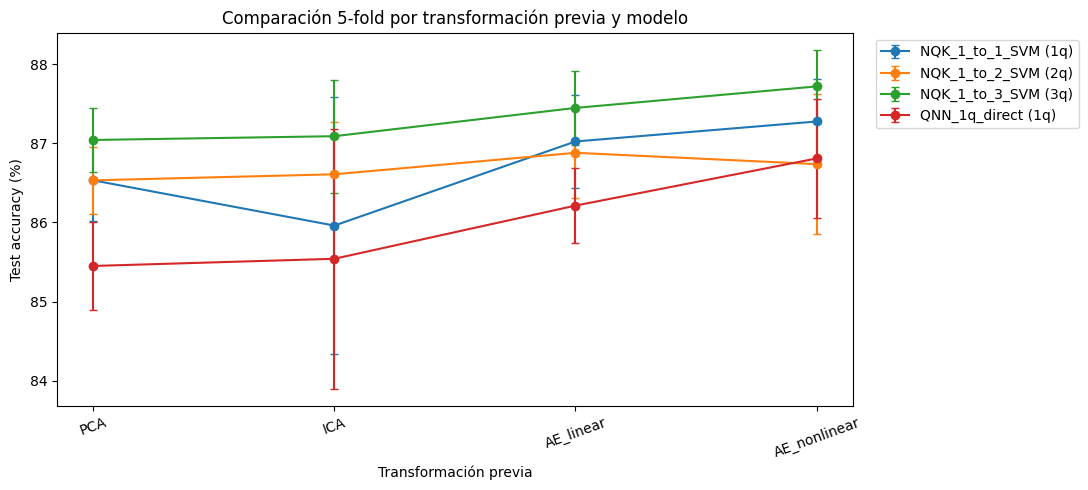

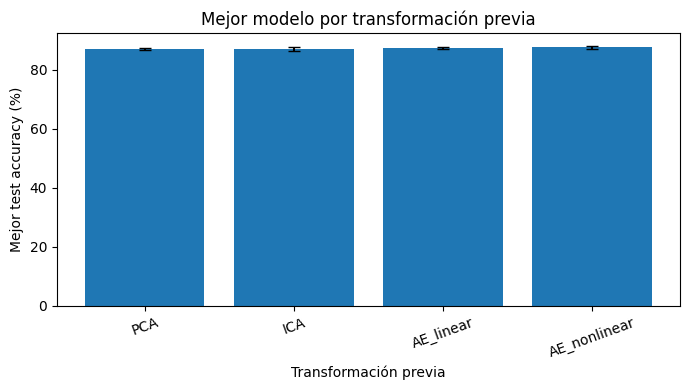

Figuras guardadas:
Satellite_3F_TransformComparison_5fold_GPU_vectorized\figures\test_acc_by_transform_and_model.png
Satellite_3F_TransformComparison_5fold_GPU_vectorized\figures\best_test_acc_per_transform.png


In [8]:
# ============================================================
# Celda 7 — Figuras resumen
# ============================================================
# Gráfica 1: test_acc por transformación y modelo.
# Gráfica 2: mejor test_acc de cada transformación.

plot_df = summary_by_model.copy()
plot_df["label"] = plot_df["model"] + " (" + plot_df["qubits"].astype(str) + "q)"

plt.figure(figsize=(11, 5))
for label, sub in plot_df.groupby("label"):
    sub = sub.set_index("transform").reindex(TRANSFORMS).reset_index()
    plt.errorbar(sub["transform"], sub["test_acc_mean"], yerr=sub["test_acc_std"], marker="o", capsize=3, label=label)
plt.xlabel("Transformación previa")
plt.ylabel("Test accuracy (%)")
plt.title("Comparación 5-fold por transformación previa y modelo")
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig1_path = os.path.join(FIGURES_DIR, "test_acc_by_transform_and_model.png")
plt.savefig(fig1_path, dpi=180)
plt.show()

plt.figure(figsize=(7, 4))
best_plot = best_per_transform.set_index("transform").reindex(TRANSFORMS).reset_index()
plt.bar(best_plot["transform"], best_plot["test_acc_mean"], yerr=best_plot["test_acc_std"], capsize=4)
plt.xlabel("Transformación previa")
plt.ylabel("Mejor test accuracy (%)")
plt.title("Mejor modelo por transformación previa")
plt.xticks(rotation=20)
plt.tight_layout()
fig2_path = os.path.join(FIGURES_DIR, "best_test_acc_per_transform.png")
plt.savefig(fig2_path, dpi=180)
plt.show()

print("Figuras guardadas:")
print(fig1_path)
print(fig2_path)

## Nota de costo computacional

Este notebook es fiel al flujo que veníamos usando, pero ahora multiplica el trabajo por:

`5 folds × 4 transformaciones × (QNN 1q + NQK 1q/2q/3q)`.

La parte más pesada es el kernel, porque por fold construye matrices `K_train = N_train × N_train`. Con todo el conjunto puede tardar bastante y usar mucha RAM. Si quieres validar que todo corre, primero pon `SAMPLE_SIZE = 2000`; cuando esté validado, vuelve a `SAMPLE_SIZE = None`.

In [10]:
# ============================================================
# CELDA EXTRA — Baselines clásicos sobre las 4 transformaciones
# SVM-RBF / Random Forest / Logistic Regression
# 5 folds sin leakage
# ============================================================

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

CLASSICAL_DIR = os.path.join(PROJECT_DIR, "classical_baselines")
os.makedirs(CLASSICAL_DIR, exist_ok=True)

classical_models = {
    "SVM_RBF": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=SEED,
        solver="lbfgs",
    ),
}

def get_transformed_fold_or_compute(X_train_raw, X_test_raw, y_train_np, y_test_np, fold, transform_name):
    """
    Usa los features 3F ya guardados por el loop principal si existen.
    Si no existen, los calcula respetando no leakage.
    """
    saved_path = os.path.join(TRANSFORM_DIR, f"features_{transform_name}_fold{fold}.npz")

    if os.path.exists(saved_path):
        data = np.load(saved_path, allow_pickle=True)
        X_train_3f = data["X_train_3f"].astype(np.float32)
        X_test_3f = data["X_test_3f"].astype(np.float32)
    else:
        X_train_3f, X_test_3f, _ = fit_transform_3f_no_leakage(
            X_train_raw, X_test_raw, y_train_np, fold, transform_name
        )

    return X_train_3f, X_test_3f


classical_rows = []
skf_classical = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

print("=" * 90)
print("BASelines clásicos 5-fold sobre transformaciones 3F")
print("=" * 90)

for fold, (train_idx, test_idx) in enumerate(skf_classical.split(X_all, y_all), start=1):
    print("\n" + "#" * 90)
    print(f"FOLD {fold}/{N_SPLITS}")
    print("#" * 90)

    X_train_raw, X_test_raw = X_all[train_idx], X_all[test_idx]
    y_train_np, y_test_np = y_all[train_idx], y_all[test_idx]

    for transform_name in TRANSFORMS:
        print(f"\nTransformación: {transform_name}")

        t0_transform = time.time()
        X_train_3f, X_test_3f = get_transformed_fold_or_compute(
            X_train_raw, X_test_raw, y_train_np, y_test_np, fold, transform_name
        )
        transform_seconds = time.time() - t0_transform

        # Escalado clásico fit SOLO con train del fold.
        # No modifica la transformación original; solo prepara bien SVM/LogReg/RF.
        scaler_cls = StandardScaler()
        X_train_cls = scaler_cls.fit_transform(X_train_3f).astype(np.float32)
        X_test_cls = scaler_cls.transform(X_test_3f).astype(np.float32)

        for model_name, base_model in classical_models.items():
            print(f"  Modelo: {model_name}")
            t0_model = time.time()

            clf = clone(base_model)
            clf.fit(X_train_cls, y_train_np)

            y_train_pred = clf.predict(X_train_cls)
            y_test_pred = clf.predict(X_test_cls)

            if hasattr(clf, "decision_function"):
                y_train_score = clf.decision_function(X_train_cls)
                y_test_score = clf.decision_function(X_test_cls)
            elif hasattr(clf, "predict_proba"):
                y_train_score = clf.predict_proba(X_train_cls)[:, 1]
                y_test_score = clf.predict_proba(X_test_cls)[:, 1]
            else:
                y_train_score = None
                y_test_score = None

            train_m = compute_metrics(y_train_np, y_train_pred, y_train_score)
            test_m = compute_metrics(y_test_np, y_test_pred, y_test_score)

            row = {
                "transform": transform_name,
                "fold": fold,
                "model": model_name,
                "qubits": 0,
                "train_acc": train_m["acc"],
                "train_f1": train_m["f1"],
                "train_precision": train_m["precision"],
                "train_recall": train_m["recall"],
                "train_auc": train_m["auc"],
                "test_acc": test_m["acc"],
                "test_f1": test_m["f1"],
                "test_precision": test_m["precision"],
                "test_recall": test_m["recall"],
                "test_auc": test_m["auc"],
                "test_tn": test_m["tn"],
                "test_fp": test_m["fp"],
                "test_fn": test_m["fn"],
                "test_tp": test_m["tp"],
                "transform_seconds": transform_seconds,
                "seconds": time.time() - t0_model,
            }
            classical_rows.append(row)

            pd.DataFrame(classical_rows).to_csv(
                os.path.join(CLASSICAL_DIR, "classical_baselines_5fold_partial.csv"),
                index=False
            )

classical_df = pd.DataFrame(classical_rows)
classical_raw_path = os.path.join(CLASSICAL_DIR, "classical_baselines_5fold_raw.csv")
classical_df.to_csv(classical_raw_path, index=False)

print("\nGuardado raw:")
print(classical_raw_path)
display(classical_df)


# ============================================================
# Resumen clásico: media ± std
# ============================================================

summary_classical = mean_std_table(
    classical_df,
    group_cols=["transform", "model", "qubits"],
    metric_cols=metric_cols,
)

summary_classical_path = os.path.join(CLASSICAL_DIR, "summary_classical_mean_std.csv")
summary_classical.to_csv(summary_classical_path, index=False)

pretty_classical_rows = []
for _, r in summary_classical.iterrows():
    pretty_classical_rows.append({
        "transform": r["transform"],
        "model": r["model"],
        "qubits": int(r["qubits"]),
        "train_acc": f"{r['train_acc_mean']:.2f} ± {r['train_acc_std']:.2f}",
        "test_acc": f"{r['test_acc_mean']:.2f} ± {r['test_acc_std']:.2f}",
        "test_f1": f"{r['test_f1_mean']:.2f} ± {r['test_f1_std']:.2f}",
        "test_auc": f"{r['test_auc_mean']:.4f} ± {r['test_auc_std']:.4f}",
        "seconds": f"{r['seconds_mean']:.1f} ± {r['seconds_std']:.1f}",
    })

pretty_classical = pd.DataFrame(pretty_classical_rows)
pretty_classical_path = os.path.join(CLASSICAL_DIR, "pretty_summary_classical.csv")
pretty_classical.to_csv(pretty_classical_path, index=False)

print("\nResumen clásico con incertidumbre:")
display(pretty_classical)
print("Saved:", pretty_classical_path)


# ============================================================
# Mejor baseline clásico por transformación
# ============================================================

best_classical_idx = summary_classical.groupby("transform")["test_acc_mean"].idxmax()
best_classical = summary_classical.loc[best_classical_idx].sort_values("test_acc_mean", ascending=False)

pretty_best_classical_rows = []
for _, r in best_classical.iterrows():
    pretty_best_classical_rows.append({
        "transform": r["transform"],
        "best_classical_model": r["model"],
        "test_acc": f"{r['test_acc_mean']:.2f} ± {r['test_acc_std']:.2f}",
        "test_f1": f"{r['test_f1_mean']:.2f} ± {r['test_f1_std']:.2f}",
        "test_auc": f"{r['test_auc_mean']:.4f} ± {r['test_auc_std']:.4f}",
        "train_acc": f"{r['train_acc_mean']:.2f} ± {r['train_acc_std']:.2f}",
    })

pretty_best_classical = pd.DataFrame(pretty_best_classical_rows)
best_classical_path = os.path.join(CLASSICAL_DIR, "pretty_best_classical_by_transform.csv")
pretty_best_classical.to_csv(best_classical_path, index=False)

print("\nMejor modelo clásico por transformación:")
display(pretty_best_classical)
print("Saved:", best_classical_path)


# ============================================================
# Comparación transformación previa x modelo clásico
# ============================================================

classical_pivot_rows = []
for (model, qubits), sub in summary_classical.groupby(["model", "qubits"]):
    row = {"model": model, "qubits": int(qubits)}
    for _, r in sub.iterrows():
        row[r["transform"]] = f"{r['test_acc_mean']:.2f} ± {r['test_acc_std']:.2f}"
    classical_pivot_rows.append(row)

classical_comparison = pd.DataFrame(classical_pivot_rows).sort_values(["model", "qubits"])
classical_comparison_path = os.path.join(CLASSICAL_DIR, "pretty_classical_comparison_transformations.csv")
classical_comparison.to_csv(classical_comparison_path, index=False)

print("\nComparación clásica entre transformaciones previas:")
display(classical_comparison)
print("Saved:", classical_comparison_path)


# ============================================================
# Comparación total opcional: QNN/NQK + clásicos
# ============================================================

if "all_results_df" in globals():
    combined_df = pd.concat([all_results_df, classical_df], ignore_index=True)
else:
    combined_df = classical_df.copy()

combined_path = os.path.join(CLASSICAL_DIR, "combined_quantum_and_classical_raw.csv")
combined_df.to_csv(combined_path, index=False)

summary_combined = mean_std_table(
    combined_df,
    group_cols=["transform", "model", "qubits"],
    metric_cols=metric_cols,
)

summary_combined_path = os.path.join(CLASSICAL_DIR, "summary_combined_quantum_classical_mean_std.csv")
summary_combined.to_csv(summary_combined_path, index=False)

pretty_combined_rows = []
for _, r in summary_combined.iterrows():
    pretty_combined_rows.append({
        "transform": r["transform"],
        "model": r["model"],
        "qubits": int(r["qubits"]),
        "train_acc": f"{r['train_acc_mean']:.2f} ± {r['train_acc_std']:.2f}",
        "test_acc": f"{r['test_acc_mean']:.2f} ± {r['test_acc_std']:.2f}",
        "test_f1": f"{r['test_f1_mean']:.2f} ± {r['test_f1_std']:.2f}",
        "test_auc": f"{r['test_auc_mean']:.4f} ± {r['test_auc_std']:.4f}",
        "seconds": f"{r['seconds_mean']:.1f} ± {r['seconds_std']:.1f}",
    })

pretty_combined = pd.DataFrame(pretty_combined_rows)
pretty_combined_path = os.path.join(CLASSICAL_DIR, "pretty_summary_combined_quantum_classical.csv")
pretty_combined.to_csv(pretty_combined_path, index=False)

print("\nComparación total QNN/NQK + clásicos:")
display(pretty_combined)
print("Saved:", pretty_combined_path)

BASelines clásicos 5-fold sobre transformaciones 3F

##########################################################################################
FOLD 1/5
##########################################################################################

Transformación: PCA
  Modelo: SVM_RBF
  Modelo: RandomForest
  Modelo: LogisticRegression

Transformación: ICA
  Modelo: SVM_RBF
  Modelo: RandomForest
  Modelo: LogisticRegression

Transformación: AE_linear
  Modelo: SVM_RBF
  Modelo: RandomForest
  Modelo: LogisticRegression

Transformación: AE_nonlinear
  Modelo: SVM_RBF
  Modelo: RandomForest
  Modelo: LogisticRegression

##########################################################################################
FOLD 2/5
##########################################################################################

Transformación: PCA
  Modelo: SVM_RBF
  Modelo: RandomForest
  Modelo: LogisticRegression

Transformación: ICA
  Modelo: SVM_RBF
  Modelo: RandomForest
  Modelo: LogisticRegression

Tr

,transform,fold,model,qubits,train_acc,train_f1,train_precision,train_recall,train_auc,test_acc,test_f1,test_precision,test_recall,test_auc,test_tn,test_fp,test_fn,test_tp,transform_seconds,seconds
0,PCA,1,SVM_RBF,0,87.318236,87.220157,88.961786,87.511378,0.930283,87.869399,87.788751,89.327949,88.050896,0.938586,2014,45,464,1673,0.191162,23.589642
1,PCA,1,RandomForest,0,100.000000,100.000000,100.000000,100.000000,1.000000,87.392755,87.373701,87.832966,87.495202,0.930256,1915,144,385,1752,0.191162,2.150454
2,PCA,1,LogisticRegression,0,87.371871,87.316068,88.390752,87.525460,0.926621,88.083889,88.037249,89.020421,88.230449,0.937248,1979,80,420,1717,0.191162,0.276812
3,ICA,1,SVM_RBF,0,87.318236,87.220157,88.961786,87.511378,0.930267,87.869399,87.788751,89.327949,88.050896,0.938565,2014,45,464,1673,0.087398,23.581989
4,ICA,1,RandomForest,0,100.000000,100.000000,100.000000,100.000000,1.000000,87.869399,87.848744,88.354955,87.976443,0.930941,1930,129,380,1757,0.087398,2.200073
5,ICA,1,LogisticRegression,0,87.371871,87.316068,88.390752,87.525460,0.926620,88.107722,88.060817,89.050668,88.254733,0.937450,1980,79,420,1717,0.087398,0.098453
6,AE_linear,1,SVM_RBF,0,87.288439,87.195838,88.846753,87.476804,0.923368,87.845567,87.768996,89.236891,88.023067,0.932696,2009,50,460,1677,0.065189,22.698198
7,AE_linear,1,RandomForest,0,100.000000,100.000000,100.000000,100.000000,1.000000,87.607245,87.591387,87.999358,87.704005,0.932227,1913,146,374,1763,0.065189,2.221401
8,AE_linear,1,LogisticRegression,0,87.383790,87.328441,88.396838,87.536939,0.926584,88.155386,88.108670,89.099341,88.302414,0.937349,1981,78,419,1718,0.065189,0.089058
9,AE_nonlinear,1,SVM_RBF,0,87.753278,87.664817,89.317081,87.941139,0.921508,88.226883,88.151811,89.645265,88.405401,0.925602,2018,41,453,1684,0.094866,22.242146



Resumen clásico con incertidumbre:


,transform,model,qubits,train_acc,test_acc,test_f1,test_auc,seconds
0,AE_linear,LogisticRegression,0,87.54 ± 0.11,87.55 ± 0.49,87.49 ± 0.49,0.9283 ± 0.0076,0.1 ± 0.0
1,AE_linear,RandomForest,0,100.00 ± 0.00,87.01 ± 0.42,86.99 ± 0.42,0.9268 ± 0.0050,2.2 ± 0.1
2,AE_linear,SVM_RBF,0,87.49 ± 0.16,87.41 ± 0.46,87.33 ± 0.46,0.9262 ± 0.0066,23.0 ± 0.2
3,AE_nonlinear,LogisticRegression,0,87.59 ± 0.34,87.54 ± 0.71,87.50 ± 0.71,0.9159 ± 0.0134,0.1 ± 0.0
4,AE_nonlinear,RandomForest,0,100.00 ± 0.00,87.59 ± 0.37,87.56 ± 0.37,0.9240 ± 0.0062,2.3 ± 0.1
5,AE_nonlinear,SVM_RBF,0,87.85 ± 0.09,87.87 ± 0.42,87.79 ± 0.43,0.9227 ± 0.0056,22.7 ± 0.4
6,ICA,LogisticRegression,0,87.57 ± 0.13,87.53 ± 0.48,87.48 ± 0.49,0.9284 ± 0.0076,0.1 ± 0.0
7,ICA,RandomForest,0,100.00 ± 0.00,87.06 ± 0.57,87.04 ± 0.57,0.9264 ± 0.0043,2.2 ± 0.1
8,ICA,SVM_RBF,0,87.53 ± 0.16,87.46 ± 0.41,87.37 ± 0.42,0.9305 ± 0.0070,23.6 ± 0.5
9,PCA,LogisticRegression,0,87.57 ± 0.13,87.53 ± 0.48,87.48 ± 0.48,0.9284 ± 0.0075,0.1 ± 0.1


Saved: Satellite_3F_TransformComparison_5fold_GPU_vectorized\classical_baselines\pretty_summary_classical.csv

Mejor modelo clásico por transformación:


...

Saved: Satellite_3F_TransformComparison_5fold_GPU_vectorized\classical_baselines\pretty_best_classical_by_transform.csv

Comparación clásica entre transformaciones previas:


,model,qubits,AE_linear,AE_nonlinear,ICA,PCA
0,LogisticRegression,0,87.55 ± 0.49,87.54 ± 0.71,87.53 ± 0.48,87.53 ± 0.48
1,RandomForest,0,87.01 ± 0.42,87.59 ± 0.37,87.06 ± 0.57,86.81 ± 0.49
2,SVM_RBF,0,87.41 ± 0.46,87.87 ± 0.42,87.46 ± 0.41,87.46 ± 0.42


Saved: Satellite_3F_TransformComparison_5fold_GPU_vectorized\classical_baselines\pretty_classical_comparison_transformations.csv

Comparación total QNN/NQK + clásicos:


,transform,model,qubits,train_acc,test_acc,test_f1,test_auc,seconds
0,AE_linear,LogisticRegression,0,87.54 ± 0.11,87.55 ± 0.49,87.49 ± 0.49,0.9283 ± 0.0076,0.1 ± 0.0
1,AE_linear,NQK_1_to_1_SVM,1,86.90 ± 0.61,87.02 ± 0.58,86.96 ± 0.58,0.9248 ± 0.0017,26.9 ± 1.1
2,AE_linear,NQK_1_to_2_SVM,2,86.73 ± 0.46,86.88 ± 0.57,86.80 ± 0.56,0.9167 ± 0.0071,28.0 ± 0.6
3,AE_linear,NQK_1_to_3_SVM,3,87.43 ± 0.29,87.45 ± 0.47,87.37 ± 0.47,0.9204 ± 0.0050,27.3 ± 0.3
4,AE_linear,QNN_1q_direct,1,86.35 ± 0.74,86.21 ± 0.48,86.13 ± 0.45,0.9264 ± 0.0048,1334.7 ± 70.9
5,AE_linear,RandomForest,0,100.00 ± 0.00,87.01 ± 0.42,86.99 ± 0.42,0.9268 ± 0.0050,2.2 ± 0.1
6,AE_linear,SVM_RBF,0,87.49 ± 0.16,87.41 ± 0.46,87.33 ± 0.46,0.9262 ± 0.0066,23.0 ± 0.2
7,AE_nonlinear,LogisticRegression,0,87.59 ± 0.34,87.54 ± 0.71,87.50 ± 0.71,0.9159 ± 0.0134,0.1 ± 0.0
8,AE_nonlinear,NQK_1_to_1_SVM,1,87.10 ± 0.46,87.28 ± 0.54,87.21 ± 0.54,0.9150 ± 0.0131,27.7 ± 0.7
9,AE_nonlinear,NQK_1_to_2_SVM,2,86.79 ± 0.84,86.74 ± 0.89,86.66 ± 0.87,0.9044 ± 0.0174,28.3 ± 0.6


Saved: Satellite_3F_TransformComparison_5fold_GPU_vectorized\classical_baselines\pretty_summary_combined_quantum_classical.csv
